# Particle with a Finite Potential

* **Author:**

* **Date:**

* **Time spent on this assignment:**

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.animation as animation
from IPython.display import HTML
def resetMe(keepList=[]):
    ll=%who_ls
    keepList=keepList+['FuncAnimation','HTML','resetMe','scipy','np','plt','math','jax','jnp','jit','grad','HTML','animation','animateMe_singlePendula']
    for iiii in keepList:
        if iiii in ll:
            ll.remove(iiii)
    for iiii in ll:
        jjjj="^"+iiii+"$"
        %reset_selective -f {jjjj}
    ll=%who_ls
    plt.rcParams.update({"font.size": 14})
    return
resetMe()
import datetime;datetime.datetime.now()

datetime.datetime(2026, 5, 3, 0, 16, 32, 897499)

In this assignment, we will consistently use grids and observables that we will set up in this way. This is very similar to how you set things for the particle in the box assignment.  We've also updated your animation code to include a skip parameter which will allow you to only show every skip'th frame.  This will make your animation generate much faster (if you choose a big skip).  It can't be called like

```
fig, ax = plt.subplots()
skip=10
max_value = np.max([np.max(np.abs(array)**2) for array in arrays[1:]])
animation = FuncAnimation(fig, update, frames=len(arrays)//skip, interval=10*skip, fargs=(skip,xs),repeat=False)
display(HTML(animation.to_jshtml()))
plt.close()
```


In [2]:
def SetupGrid(L,delta_x):
    n=int(round(L/delta_x))+1
    xs=np.linspace(-L/2,L/2,n,endpoint=True)
    return xs

def SetupObservables(xs,delta_x):
    X=np.diag(xs)
    P=(np.diag([-1.j/(2*delta_x) for i in range(len(xs)-1)],k=1)+np.diag([1.j/(2*delta_x) for i in range(len(xs)-1)],k=-1))

    P2=np.zeros_like(P)
    for i in range(len(xs)):
        P2[i,i]=2.0/delta_x**2
        if i+1<len(xs):
            P2[i,i+1]=-1.0/delta_x**2
            P2[i+1,i]=-1.0/delta_x**2
    return X,P,P2

def update(frame, skip, xs, positions=None, potential=[], max_value=0, energy=0,scale=0):
    plt.cla()  # Clear the current plot
    scale=max_value/energy
    plt.axhline(energy*scale, color='red', linestyle='--')
    plt.plot(xs,potential*scale)
    if type(positions)==np.ndarray:
        plt.axvline(positions[::skip][frame], color='green', linestyle='-')
    elif positions!=None:
        print("ERROR")
        return
    plt.plot(xs, np.abs(arrays[::skip][frame])**2)  # Plot the current array
    plt.ylim(0, 1.5*max_value)  # Set the y-axis limit
    plt.xlabel('x')
    plt.ylabel('Value')
    plt.title(f'Frame {skip*frame+1}/{len(arrays)}')  # Display the frame number


## Exercise 1. Particle in a Finite Well

In the previous assignment we worked on a particle in a box with infinite walls.  In this assignment, we are going to work instead with a potential well again looking at properties such as eigenstates and time dynamics.

### a. Setting up the Hamiltonian


Consider a particle in a box of length 40 spanning
* $-10 \leq x \leq 10$ at $V=0$
* $-20 \leq x \leq -10$ at $V=0.5$
* $10 \leq x \leq 20$ at $V=0.5$

Generate a discretize `xs` with the same $\delta x=0.01$ that you used previously - i.e. `xs=SetupGrid(L,delta_x)`
Also generate a numpy array `potential` which has the correct potential at each value of $x$.  Verify this all looks correct by plotting $V$ vs. $x$.

It will also be convenient here to setup your observables using
```
X,P,P2=SetupObservables(xs,delta_x)
```
although we won't use them till later

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

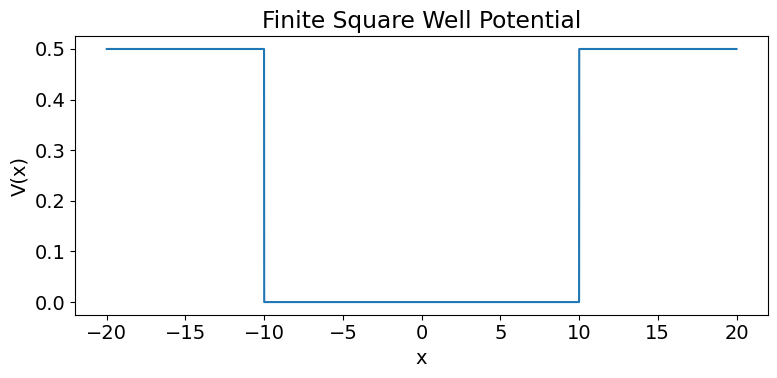

In [ ]:
L = 40
delta_x = 0.01
xs = SetupGrid(L, delta_x)

potential = np.where(np.abs(xs) <= 10, 0.0, 0.5)

X, P, P2 = SetupObservables(xs, delta_x)

plt.figure(figsize=(8, 4))
plt.plot(xs, potential)
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Finite Square Well Potential')
plt.tight_layout()
plt.show()

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

We know need to again set up the Hamiltonian

$$ H \equiv \left( -\frac{\hbar^2}{2m} \frac{\partial^2}{\partial x^2}  + V \right)  $$

You already know how to turn the first term into a matrix.  Because we are working in the $x$ basis, the $V$ term is also very simple:  it is just a matrix with $V(x)$ (`np.diag(V)`) on the diagonal.   To get the matrix for the total Hamiltonian, we just add these two matrices.

Set up this Hamiltonian, and then get the eigenvalues and eigenvectors.

Plot the first 20 eigenvalues.  You should notice that there is two qualitatively different behavior happening that switches over when the eigenvalue energy gets greater then 0.5 (where our potential wall is.)


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

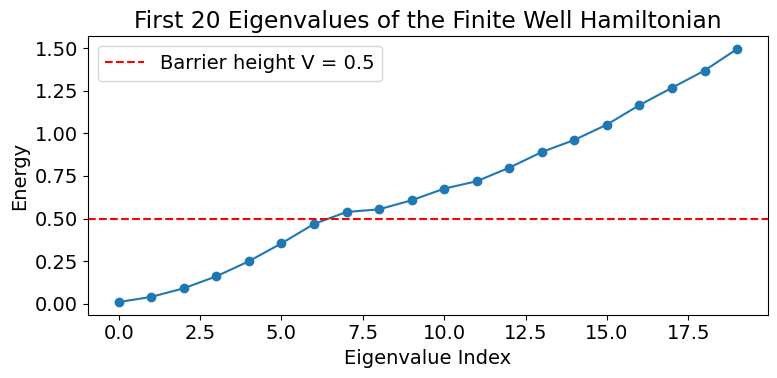

In [10]:
H = 0.5 * P2 + np.diag(potential)
e, v = np.linalg.eigh(H)

plt.figure(figsize=(8, 4))
plt.plot(range(20), e[:20], 'o-', markersize=6)
plt.axhline(0.5, color='red', linestyle='--', label='Barrier height V = 0.5')
plt.xlabel('Eigenvalue Index')
plt.ylabel('Energy')
plt.title('First 20 Eigenvalues of the Finite Well Hamiltonian')
plt.legend()
plt.tight_layout()
plt.show()

**Eigenvalues below E = 0.5 are discrete bound states with increasing spacing, while those above E = 0.5 become closely-packed, transitioning to the quasi-continuum of an unbound (scattering) particle confined to the full box.**

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

Now we would like to plot the energies in a slightly different way and plot the eigenvectors on top of them.  Let's start by again plotting the potential as a function of distance.  

On top of this potential we are going to plot the lowest 10 energy levels.  Plot them with `plt.axhline(the_ith_energy,linestyle='--',alpha=0.5)`  You should notice that some of the energies are less then the potential and some of them more then the potential.


Now on top of this, we want to plot the lowest 10 eigenstates.   To make them easier to understand, let's shift each eigensstate vertically by adding `e[i]` to the i'th eigenstate - i.e. `plt.plot(v[:,i]+e[i])`.  Notice that if you do this, you have each eigenstate whose origin is centered on their energy.


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


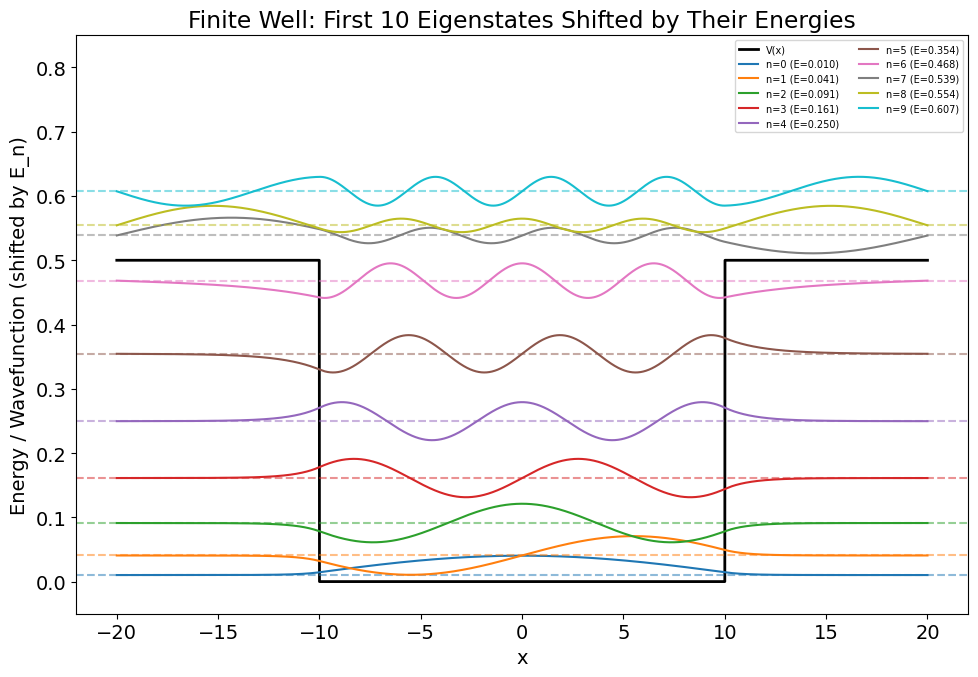

In [11]:
plt.figure(figsize=(10, 7))
plt.plot(xs, potential, 'k-', linewidth=2, label='V(x)')
for i in range(10):
    plt.axhline(e[i], linestyle='--', alpha=0.5, color=f'C{i}')
    plt.plot(xs, v[:, i] + e[i], color=f'C{i}', label=f'n={i} (E={e[i]:.3f})')
plt.ylim(-0.05, 0.85)
plt.xlabel('x')
plt.ylabel('Energy / Wavefunction (shifted by E_n)')
plt.title('Finite Well: First 10 Eigenstates Shifted by Their Energies')
plt.legend(loc='upper right', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### b.  Eigenstates in the forbidden region

We now want to look at the eigenstates in the forbidden region.  To begin with, let's just qualitatively notice the difference between the eigenstates which are lower in energy then the finite wall and the ones that are higher in energy then the finite wall.  


Q:  As the wave-function goes to $x>10$, do the eigenstates approach zero  
* for the eigenstates whose energy is greater then 0.5
* for the eigenstates whose energy is less then 0.5

When the energy is larger then the potential, notice that the larger tha value of (E-V) (at a given $x$), the shorter the wavelength of the wave.

When the energy is smaller then the potential (i.e. in the forbidden region), we know that the eigenstate should decay exponentially.  

We have learned that when an eigenstate is in the forbidden region it should decay exponentially.  
That means that if we look at any of the eigenstates with $e_i<0.5$, we should find that they approach zero exponentially.  It might look that way by eye, but we want to check this explicitly.  

First, we need to learn how to extract the part of the wave-function where the energy is less then 0.5.  To do this, we should define a mask - i.e. `mask=xs>10` to focus on the forbidden region.

Then we can plot the absolute value of the eigenstate (because the eigenstate can approach zero from below) against xs only in this region - i.e. `plt.plot(xs[mask],v[:,n][mask])` for eigenstates $n \in \{0,2,4\}$.  Label each of your plots by including as a keyword `label=n` and then add a `plt.legend()` at the end.

Then go ahead and plot it on a log-scale - `plt.yscale('log')`.  If it looks linear on a log scale, this means that the wave-function is decaying exponentially.  In practice, it may look like it diverges from that linear curve at large $x$.  This is essentially because you are running into machine precision.  Notice that the lower-energy eigenstates have larger slopes (i.e. decay faster);  this is because they are deeper in the forbidden region.


We can actually quantify this (*this part is optional but interesting if you want to show that you get exactly the correct exponential decay*).  Our expectation is that the wave-function goes as $e^{-kx}$ where

$$k=\sqrt{\frac{2m(E-V_0)}{\hbar^2}}$$

This means that if we plot the slopes squared of these three lines versus $e_i-0.5$ where $e_i$ is the eigenstate energy, it should be a straight line with a slope of -2.

In order to get the slopes of the three lines, we can use python to fit them.  Again let's define a mask that is simultaneously both in the forbidden region and not at large $x$ where the machine precision starts to cause trouble: `mask=np.logical_and(xs>10,xs<16)`

Now use `np.polyfit(x,y,1)[0]` to get the slope.  Remember that `y` needs to be the log of the wave-function (appropriately masked).

Then plot the slope-squared versus the energy difference from 0.5  You should fine a straight line.

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

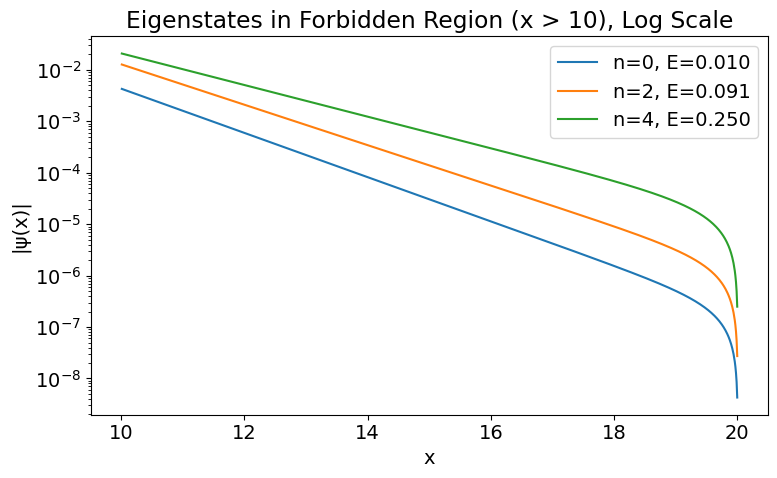

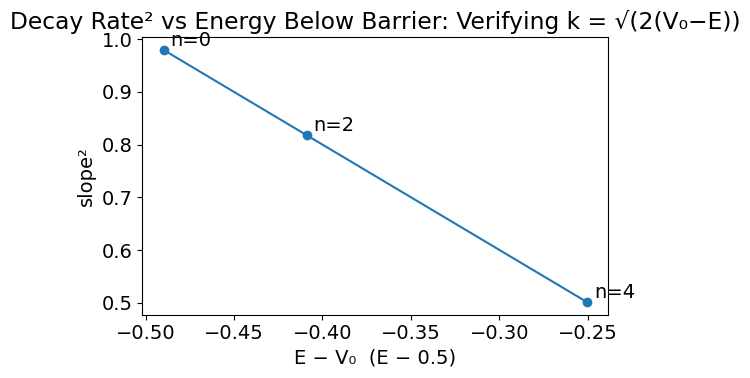

**The wavefunctions decay exponentially in the forbidden region (linear on a log scale), and the linear relationship slope² ∝ (V₀ − E) confirms the quantum mechanical prediction k = √(2m(V₀ − E)/ℏ²) with m = ℏ = 1.**

In [12]:
# Plot eigenstates in forbidden region (x > 10) on log scale
plt.figure(figsize=(8, 5))
mask = xs > 10
for n in [0, 2, 4]:
    plt.plot(xs[mask], np.abs(v[:, n][mask]), label=f'n={n}, E={e[n]:.3f}')
plt.yscale('log')
plt.xlabel('x')
plt.ylabel('|ψ(x)|')
plt.title('Eigenstates in Forbidden Region (x > 10), Log Scale')
plt.legend()
plt.tight_layout()
plt.show()

# Fit exponential decay slopes in the well-behaved part of the forbidden region
mask_fit = np.logical_and(xs > 10, xs < 16)
slopes = []
energies_fit = []
for n in [0, 2, 4]:
    log_psi = np.log(np.abs(v[:, n][mask_fit]) + 1e-30)
    slope = np.polyfit(xs[mask_fit], log_psi, 1)[0]
    slopes.append(slope)
    energies_fit.append(e[n])

slope_sq = [s**2 for s in slopes]
energy_diff = [en - 0.5 for en in energies_fit]

plt.figure(figsize=(6, 4))
plt.plot(energy_diff, slope_sq, 'o-')
for i, n in enumerate([0, 2, 4]):
    plt.annotate(f'n={n}', (energy_diff[i], slope_sq[i]),
                 textcoords='offset points', xytext=(5, 3))
plt.xlabel('E − V₀  (E − 0.5)')
plt.ylabel('slope²')
plt.title('Decay Rate² vs Energy Below Barrier: Verifying k = √(2(V₀−E))')
plt.tight_layout()
plt.show()

from IPython.display import Markdown
display(Markdown("**The wavefunctions decay exponentially in the forbidden region (linear on a log scale), and the linear relationship slope² ∝ (V₀ − E) confirms the quantum mechanical prediction k = √(2m(V₀ − E)/ℏ²) with m = ℏ = 1.**"))

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c. Dynamics

Like we did in the particle in the box, we are going to do some dynamics.

Because we are going to do some non-trivial time evolution in this assignment, it's worth encapsulating your time-evolution into two functions:

* `TimeEvolutionOperator(H,delta_t)` should take the Hamiltonian and your time step and return $e^{-iHt}$.   It's important to note that for each Hamiltonian, you only need to compute this time-evolution operator once even if you are time-evolving many different wave-functions. If you are careful about this, you will save yourself significant time.

* `TimeEvolution(psi,M,steps)` which takes the initial wave-function `psi`, the time-evolution operator `M` and the number of steps and returns a list of arrays that include the snapshot of the wave-function at every time step.

ou will need to give `def update(frame, skip, xs, positions, potential, max_value, energy)`  the relevant additional parameters. `max_value` is the largest probability your wave-function gets (which we've already been calculating for animation) and `energy` is the energy of our initial wave-function, which you can compute (recall the energy doesn't change as a function of time).  You also need to send it the position array which you can compute using your `X` from `SetupObservables` (outside the function) - e.g.
```
 X,P,P2=SetupObservables(xs,delta_x)
 ```

We will start with the wave-function (same superposition of eigenstates as our particle-in-the-box but somewhat different eigenstates so a somewhat different wave-function)

$$|\Psi\rangle = \sqrt{0.1}|v_0\rangle + \sqrt{0.25}|v_1\rangle + i \sqrt{0.65}|v_2\rangle $$

Go ahead and animate this wave-function as a function of time again for a time-step $\delta t=0.5$ and out to time $T=200$.  

Seperately and, in addition, plot the snapshots at $T=0,100,200$ in one plot.

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [13]:
def TimeEvolutionOperator(H_op, delta_t):
    return scipy.linalg.expm(-1.j * delta_t * H_op)

def TimeEvolution(psi_te, M_te, steps_te):
    result = [psi_te.copy()]
    for _ in range(steps_te):
        psi_te = M_te @ psi_te
        result.append(psi_te.copy())
    return result

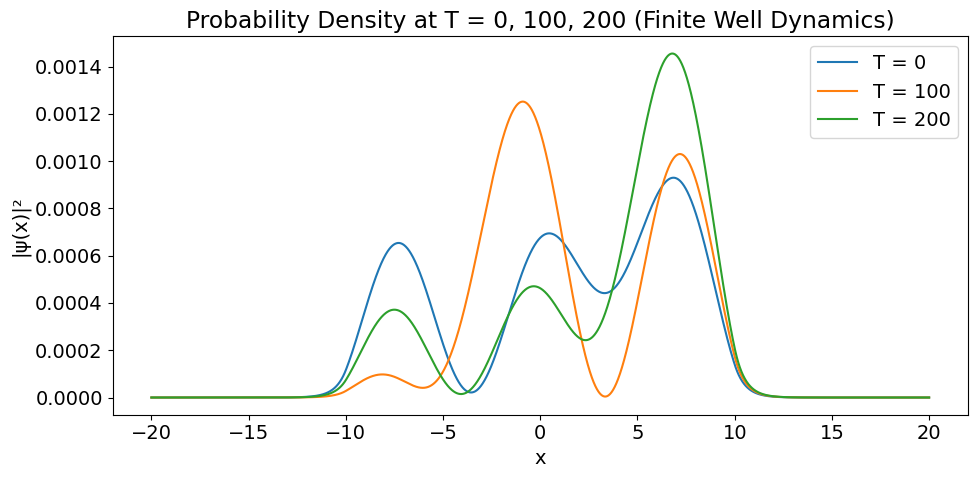

In [14]:
psi0 = np.sqrt(0.1) * v[:, 0] + np.sqrt(0.25) * v[:, 1] + 1.j * np.sqrt(0.65) * v[:, 2]

delta_t = 0.5
T_total = 200
steps = int(T_total / delta_t)

M = TimeEvolutionOperator(H, delta_t)
arrays = TimeEvolution(psi0, M, steps)

# Snapshots at T = 0, 100, 200
plt.figure(figsize=(10, 5))
for t_snap in [0, 100, 200]:
    frame_idx = int(t_snap / delta_t)
    plt.plot(xs, np.abs(arrays[frame_idx])**2, label=f'T = {t_snap}')
plt.xlabel('x')
plt.ylabel('|ψ(x)|²')
plt.title('Probability Density at T = 0, 100, 200 (Finite Well Dynamics)')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Compute energy and max probability for animation scaling
energy_psi0 = np.real(psi0.conj() @ H @ psi0)
max_value = np.max([np.max(np.abs(arr)**2) for arr in arrays[1:]])

fig, ax = plt.subplots()
skip = 10
anim = FuncAnimation(fig, update, frames=len(arrays) // skip, interval=10 * skip,
                     fargs=(skip, xs, None, potential, max_value, energy_psi0), repeat=False)
display(HTML(anim.to_jshtml()))
plt.close()

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

If you go back and look at your animation from the particle-in-a-box, it actually should look very similar.  The main different here is that the particle has leaked out slightly of the hard box (-10 to 10) and so you see some weight out there.

Let's also go ahead and plot some observables.  Like you did in the particle-in-a-box go ahead and plot

* the momentum and position as a function of time (on the same subplot)
* the phase plot of momentum vs position
* the energy as a function of time (making sure your scale is sane)



<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

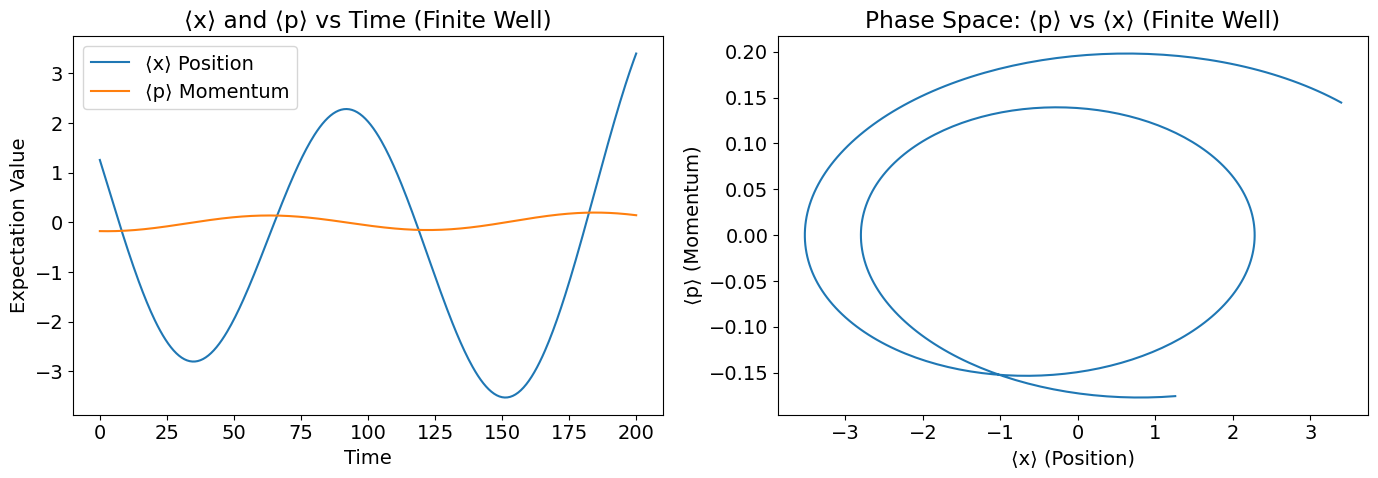

In [18]:
# Compute position, momentum, and energy as a function of time
positions_t = []
momenta_t = []
energies_t = []
times_t = np.arange(len(arrays)) * delta_t

for psi in arrays:
    positions_t.append(np.real(psi.conj() @ X @ psi))
    momenta_t.append(np.real(psi.conj() @ P @ psi))
    energies_t.append(np.real(psi.conj() @ H @ psi))

# Position and momentum vs time on same subplot, plus phase space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(times_t, positions_t, label='⟨x⟩ Position')
axes[0].plot(times_t, momenta_t, label='⟨p⟩ Momentum')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Expectation Value')
axes[0].set_title('⟨x⟩ and ⟨p⟩ vs Time (Finite Well)')
axes[0].legend()

axes[1].plot(positions_t, momenta_t)
axes[1].set_xlabel('⟨x⟩ (Position)')
axes[1].set_ylabel('⟨p⟩ (Momentum)')
axes[1].set_title('Phase Space: ⟨p⟩ vs ⟨x⟩ (Finite Well)')
plt.tight_layout()
plt.show()

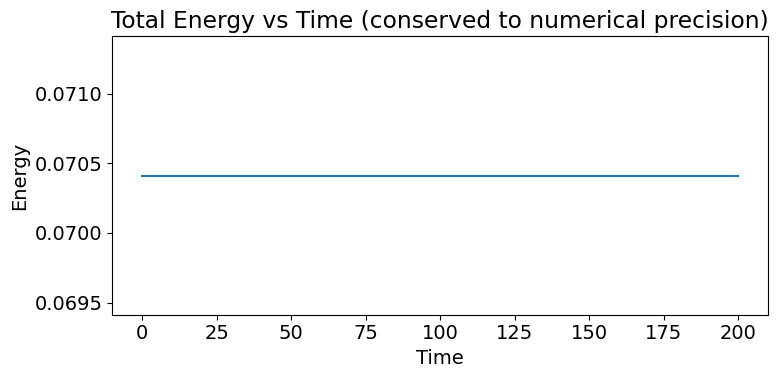

**Energy is conserved to numerical precision throughout the dynamics, while ⟨x⟩ and ⟨p⟩ oscillate quasi-periodically and trace a closed ellipse in phase space, reflecting quasi-harmonic confinement inside the finite well.**

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(times_t, energies_t)
e_mean = np.mean(energies_t)
plt.ylim(e_mean - 0.001, e_mean + 0.001)
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Total Energy vs Time (conserved to numerical precision)')
plt.tight_layout()
plt.show()

from IPython.display import Markdown
display(Markdown("**Energy is conserved to numerical precision throughout the dynamics, while ⟨x⟩ and ⟨p⟩ oscillate quasi-periodically and trace a closed ellipse in phase space, reflecting quasi-harmonic confinement inside the finite well.**"))

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

Again notice the marked similarity to a particle in a box with infinite walls.

### d.  Dynamics above the potential barrier

In this problem, let us consider a superposition of eigenstates that is above the potential barrier. For example, let's take the superposition of eigenstates 9 and 10 (both above the potential) as

$$\Psi= \sqrt{0.35}|v_9\rangle + i \sqrt{0.65}|v_{10}\rangle$$

Produce the same set of animations and observable plots for this wave-function.  

Notice in this case that significant chunks of the wave-function are in the forbidden region.

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

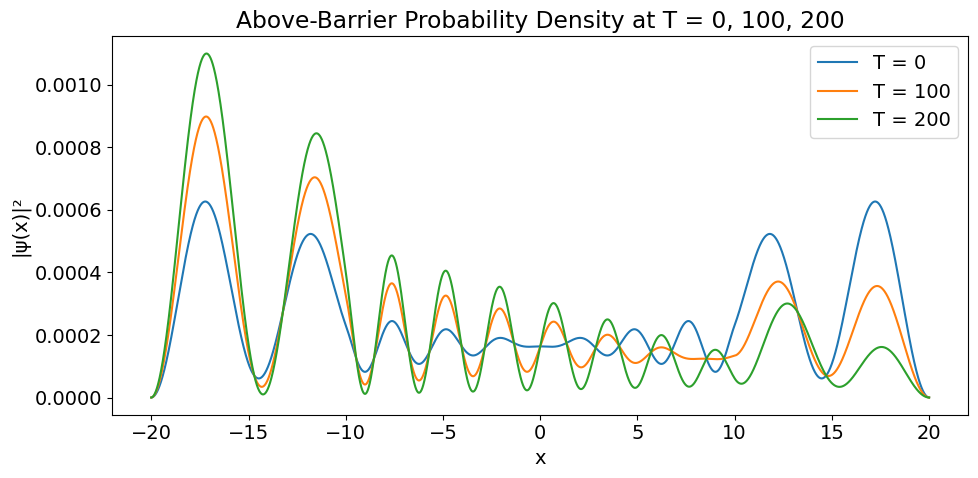

In [20]:
# Superposition of eigenstates 9 and 10 (both above the barrier V = 0.5)
psi_d = np.sqrt(0.35) * v[:, 9] + 1.j * np.sqrt(0.65) * v[:, 10]

arrays_d = TimeEvolution(psi_d, M, steps)

# Snapshots at T = 0, 100, 200
plt.figure(figsize=(10, 5))
for t_snap in [0, 100, 200]:
    frame_idx = int(t_snap / delta_t)
    plt.plot(xs, np.abs(arrays_d[frame_idx])**2, label=f'T = {t_snap}')
plt.xlabel('x')
plt.ylabel('|ψ(x)|²')
plt.title('Above-Barrier Probability Density at T = 0, 100, 200')
plt.legend()
plt.tight_layout()
plt.show()

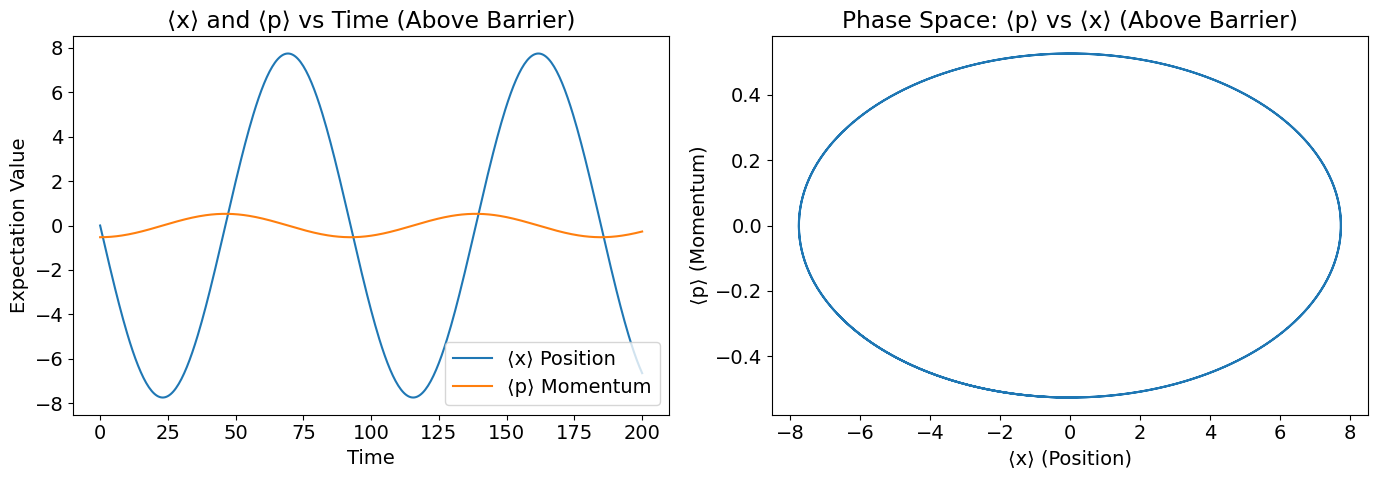

In [21]:
# Observables for above-barrier state
positions_d = []
momenta_d = []
energies_d = []

for psi in arrays_d:
    positions_d.append(np.real(psi.conj() @ X @ psi))
    momenta_d.append(np.real(psi.conj() @ P @ psi))
    energies_d.append(np.real(psi.conj() @ H @ psi))

# Position and momentum vs time, plus phase space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(times_t, positions_d, label='⟨x⟩ Position')
axes[0].plot(times_t, momenta_d, label='⟨p⟩ Momentum')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Expectation Value')
axes[0].set_title('⟨x⟩ and ⟨p⟩ vs Time (Above Barrier)')
axes[0].legend()

axes[1].plot(positions_d, momenta_d)
axes[1].set_xlabel('⟨x⟩ (Position)')
axes[1].set_ylabel('⟨p⟩ (Momentum)')
axes[1].set_title('Phase Space: ⟨p⟩ vs ⟨x⟩ (Above Barrier)')
plt.tight_layout()
plt.show()

In [ ]:
# Energy vs time
plt.figure(figsize=(8, 4))
plt.plot(times_t, energies_d)
e_d_mean = np.mean(energies_d)
plt.ylim(e_d_mean - 0.001, e_d_mean + 0.001)
plt.xlabel('Time')
plt.ylabel('Energy')
plt.title('Total Energy vs Time (Above Barrier, conserved)')
plt.tight_layout()
plt.show()

# Animation for above-barrier state
energy_d_val = np.real(psi_d.conj() @ H @ psi_d)
max_value_d = np.max([np.max(np.abs(arr)**2) for arr in arrays_d[1:]])
arrays = arrays_d  # set global for update()

fig, ax = plt.subplots()
skip = 10
anim = FuncAnimation(fig, update, frames=len(arrays) // skip, interval=10 * skip,
                     fargs=(skip, xs, None, potential, max_value_d, energy_d_val), repeat=False)
display(HTML(anim.to_jshtml()))
plt.close()

from IPython.display import Markdown
display(Markdown("**Above the potential barrier, the wavefunction extends significantly into the classically forbidden region (|x| > 10) and the phase-space trajectory is more irregular, reflecting the richer spatial structure of unbound eigenstates.**"))

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

## Exercise 2. Eigenstates of Finite Barriers

### a. Diagonalize

Now we will consider a potential with a finite barrier.  Set the potential to be zero except for the range $-1<x<1$ where we will have the potential be $V_0=5$.  Use $L=20$

Start by plotting the potential.

Then plot the lowest two 5 eigenvalues and 2 eigenvectors.   What you will find is that the two lowest eigenvectors are nearly degenerate - they have almost the same energy. Why is this?  Can you tell from the actual eigenvectors that this would have been the case?


For this problem, it will run much faster if you use a more reasonable $\delta x = 0.1$
```
delta_x=0.1
xs=SetupGrid(L,delta_x)
```

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

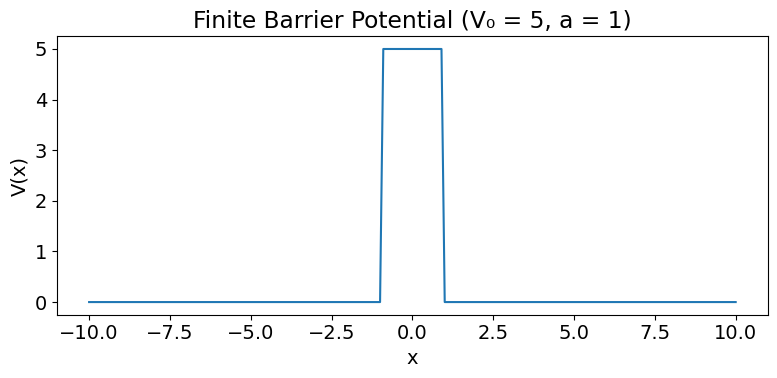

/var/folders/73/qbtgrjk170gbr1jv1z208qg00000gn/T/ipykernel_79862/2221729966.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


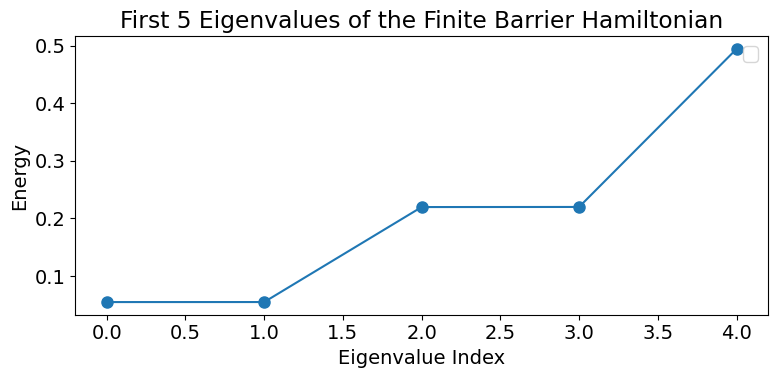

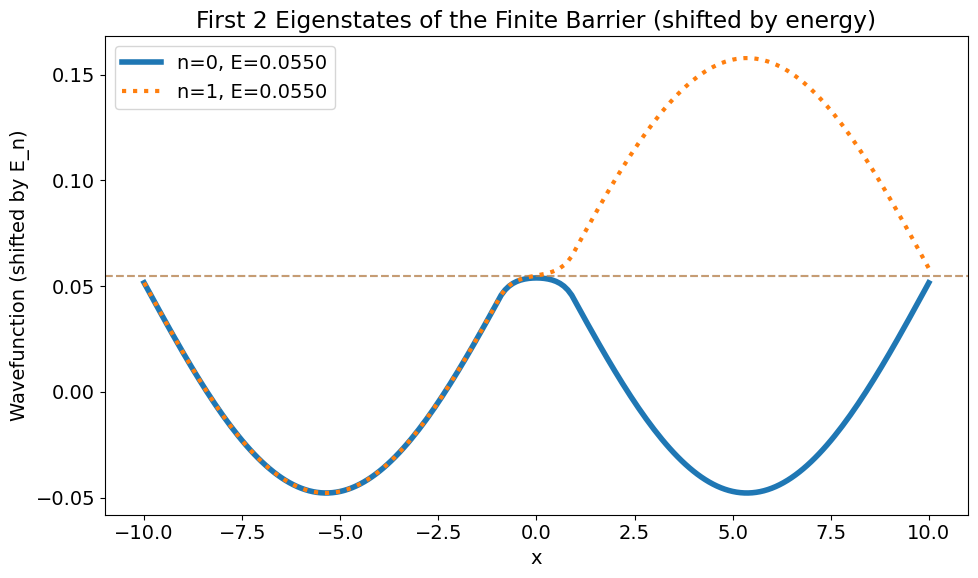

In [34]:
L = 20
delta_x = 0.1
xs = SetupGrid(L, delta_x)
X, P, P2 = SetupObservables(xs, delta_x)

# Finite barrier: V₀ = 5 for -1 < x < 1, zero otherwise
potential_b = np.where(np.abs(xs) < 1, 5.0, 0.0)

plt.figure(figsize=(8, 4))
plt.plot(xs, potential_b)
plt.xlabel('x')
plt.ylabel('V(x)')
plt.title('Finite Barrier Potential (V₀ = 5, a = 1)')
plt.tight_layout()
plt.show()

# Hamiltonian and eigenstates
H_b = 0.5 * P2 + np.diag(potential_b)
e_b, v_b = np.linalg.eigh(H_b)

# First 5 eigenvalues
plt.figure(figsize=(8, 4))
plt.plot(range(5), e_b[:5], 'o-', markersize=8)
plt.xlabel('Eigenvalue Index')
plt.ylabel('Energy')
plt.title('First 5 Eigenvalues of the Finite Barrier Hamiltonian')
plt.legend()
plt.tight_layout()
plt.show()

# First 2 eigenvectors overlaid on potential
plt.figure(figsize=(10, 6))
for i in range(2):
    plt.axhline(e_b[i], linestyle='--', alpha=0.5, color=f'C{i}')
    if i == 0:
        plt.plot(xs, v_b[:, i] + e_b[i], color=f'C{i}', linestyle='-', linewidth=4, label=f'n={i}, E={e_b[i]:.4f}')
    else:
        plt.plot(xs, v_b[:, i] + e_b[i], color=f'C{i}', linestyle=':', linewidth=3)
plt.xlabel('x')
plt.ylabel('Wavefunction (shifted by E_n)')
plt.title('First 2 Eigenstates of the Finite Barrier (shifted by energy)')
plt.legend(handles=[
    plt.Line2D([0], [0], color='C0', linestyle='-', linewidth=4, label=f'n=0, E={e_b[0]:.4f}'),
    plt.Line2D([0], [0], color='C1', linestyle=':', linewidth=3, label=f'n=1, E={e_b[1]:.4f}')
])
plt.tight_layout()
plt.show()

**The two lowest eigenstates are nearly degenerate because the central barrier divides the box into two weakly coupled wells; the symmetric and antisymmetric combinations of their ground states have nearly identical energies due to exponentially small tunneling through the barrier.**

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

## Exercise 3. Faster Dynamics and Finite Barriers

So far we've done dynamics by evaluating $\exp[-i \Delta t H]$ for a finite $\Delta t$. This has the advantage of being the exact dynamics but when $L$ is large or $\Delta x$ is small this gets very expensive to calculate limiting our ability to do interesting calculations.

Here we are going to introduce an alternative approach.   Consider the time-evolution operator

$$\exp\left[-i\Delta t\left(-\frac{\hat{P}^2}{2m} + \hat{V} \right) \right]^{T/\Delta t}  |\Psi\rangle$$

When $\Delta t \rightarrow 0$, we can write this as

$$\left(\exp\left[-i\Delta t\left(-\frac{\hat{P}^2}{2m}\right)\right] \exp\left[-i \Delta t \hat{V} \right]\right)^{T/\Delta t}  |\Psi\rangle$$

Instead of thinking of time-evolution as applying the exponential of the Hamiltonian, we can think of time evolution as alternatively applying the exponential of the potential and kinetic terms.

If our wave-function is a vector in the position basis (which it mainly has been), then applying the potential term (treating `V` as an array - earlier we called it `potential`) is very easy because multiplying by a diagonal matrix is the same as pointwise multiplying by a vector - i.e.  all three of these lines below are equivalent:
```
scipy.linalg.expm(-1.j*dt*np.diag(V)) @ psi
np.diag(np.exp(-1.j*dt*V)) @ psi
np.exp(-1.j*dt*V) * psi
```
The first line is the sort of thing we've been doing all along (but just with the potential piece).
The last line doesn't involve a matrix at all but just a vector.  Let us define `M_half_x=np.exp(-1.j*dt/2*np.diag(V))`

Unfortunately, the kinetic piece is complicated if our wave-function is in the position basis. But.... if our wave-function is in the momentum basis, then it would be easy because in the momentum basis that matrix is diagonal so we can just pointwise multiply by the vector `M_p=np.exp(-1.j* dt* (ks**2)/(2*m))`.

But it's easy to move the wave-function back and forth between the position and momentum basis via an FFT so we can always be in the "good" basis when we have to apply the operator.

This leaves us with the following algorithm to apply a single time-step $\Delta t$ starting with a wave-function `psi` in the position basis:
* (1) apply  M_half_x to psi
* (2) apply  M_half_x to psi
* (3) switch to the momentum basis `psi_k=np.fft.fft(psi)`
* (4) apply M_p to psi_k
* (5) switch to the real space basis `psi=np.fft.ifft(psi_k)`

We then need to do this over and over again for many time-steps  (for technical reasons, it's actually more accurate to put (1) after (5)).

You are making a tiny error in $\Delta t$ but this algorithm is much better then our previous approaches.  You never need to build a big matrix diagonalize a Hamiltonian, etc.  To implement this you will need the k-vectors `ks=np.fft.fftfreq(len(xs), delta_x)*(2*np.pi)`

There is one additional wart.  This will only work on wave-functions that go to zero at the edge of your box but since you can use such a large box this shouldn't be a problem.


### a. Fast Time evolution for the Finite Well

In this part, we will do time evolution again on the finite well but this time much more efficiently.  The finite well parameters we will use are

- dt=0.01
- delta_x=0.1
- L=40 (for a width of 80)
- T=1 (this will be the time at which your Time Evolution runs - you will run it many times but each time saving a snapshot at each $T$)
- an initial wave-function $|\Psi\rangle = \sqrt{0.1}|v_0\rangle + \sqrt{0.25}|v_1\rangle + i \sqrt{0.65}|v_2\rangle $ generated from the finite-well potential with $V(x)=0.5$ when $|x|>10$ and $V(x)=0$ otherwise. (to get $\Psi$, you will need to work with your Hamiltonian again which is slow - this is just for a test).


Write a function
```
def SetupWell():
  # do stuff here
    return psi_init,V,dt,T,xs,freqs
```

which returns the relevant initial wave-function, potential, time-step, time-per-snapshot, grid, and frequencies.  recall that
 the frequencies that correspond to our fft are
- `freqs = np.fft.fftfreq(len(xs), delta_x)*(2*np.pi)`

Now write a function `def TimeEvolution(T,dt,V,psi,freqs)` which does the time-evolution returning the new `psi`.

Run your time-evolution out to time $400T$ like

```
psi,V,dt,T,xs,freqs=SetupWell()
arrays=[psi]
for step in range(0,400):
    psi=TimeEvolution(T, dt, V, psi, freqs)
    arrays.append(psi)
```

If you plot the probability density of the wave-function at time $40T$ you should see the wave-function in the  potential barrier with the weight to the left.
```
plt.plot(xs,V/200)
plt.plot(xs,np.abs(arrays[40])**2)
```

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

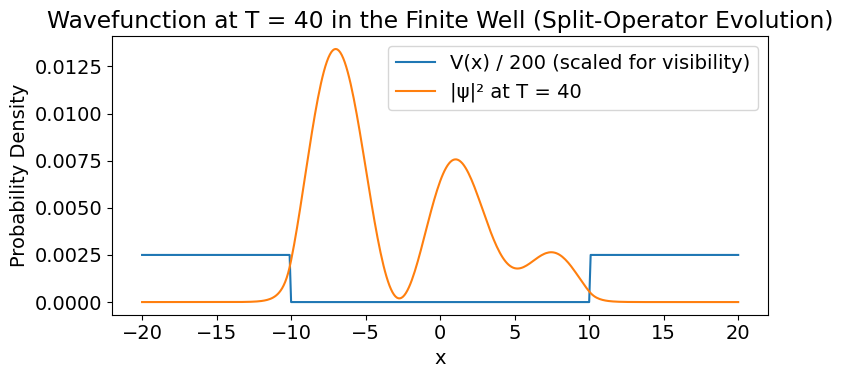

In [41]:
def SetupWell():
    L_w = 40
    delta_x_w = 0.1
    dt_w = 0.01
    T_w = 1.0
    xs_w = SetupGrid(L_w, delta_x_w)
    freqs_w = np.fft.fftfreq(len(xs_w), delta_x_w) * (2 * np.pi)
    V_w = np.where(np.abs(xs_w) <= 10, 0.0, 0.5)

    # Build Hamiltonian to get eigenstates for initial state construction
    _, _, P2_w = SetupObservables(xs_w, delta_x_w)
    H_w = 0.5 * P2_w + np.diag(V_w)
    e_w, v_w = np.linalg.eigh(H_w)

    psi_init = (np.sqrt(0.1) * v_w[:, 0] +
                np.sqrt(0.25) * v_w[:, 1] +
                1.j * np.sqrt(0.65) * v_w[:, 2])
    return psi_init, V_w, dt_w, T_w, xs_w, freqs_w


def TimeEvolution(T_ev, dt_ev, V_ev, psi_ev, freqs_ev):
    """Split-operator (Strang) time evolution via FFT."""
    n_steps = int(round(T_ev / dt_ev))
    M_half_x = np.exp(-1.j * dt_ev / 2.0 * V_ev)
    M_p = np.exp(-1.j * dt_ev * freqs_ev**2 / 2.0)
    for _ in range(n_steps):
        psi_ev = M_half_x * psi_ev          # half potential step
        psi_k = np.fft.fft(psi_ev)
        psi_k = M_p * psi_k                 # full kinetic step
        psi_ev = np.fft.ifft(psi_k)
        psi_ev = M_half_x * psi_ev          # half potential step
    return psi_ev


psi, V, dt, T, xs, freqs = SetupWell()
arrays = [psi]
for step in range(0, 400):
    psi = TimeEvolution(T, dt, V, psi, freqs)
    arrays.append(psi)

plt.figure(figsize=(8, 4))
plt.plot(xs, V / 200, label='V(x) / 200 (scaled for visibility)')
plt.plot(xs, np.abs(arrays[40])**2, label='|ψ|² at T = 40')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Wavefunction at T = 40 in the Finite Well (Split-Operator Evolution)')
plt.legend()
plt.tight_layout()
plt.show()

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (start)"></img><br></div>

### b. Plotting our time-evolution

Now we would like to plot some data.   

We want to plot
- the probability density of the wave-function in real space at time $50T$
- the probability density of the wave-function in k-space at time $50T$
- the average position as a function of time (**you shouldn't need anything from SetupObservables for this such as the X or P**)
- the momentum as a function of time (you shouldn't need anything from SetupObservables for this)
- the total, kinetic, and potential energy as a function of time (on one plot)  (you shouldn't need anything from SetupObservables for this)
- the potential

Write `GetEnergy(psis,freqs)` and `GetAverages(psis,xs,freqs)` which return these observables and plot them.

You can plot it however you want but I plotted it like this to get it into subplots
```
fig, ax = plt.subplots(2, 3)
fig.set_figwidth(22)
fig.set_figheight(12)

ax[0,0].plot(np.array(range(len(Es)))*dt,Es,label='Total Energy')
ax[0,0].plot(np.array(range(len(PEs)))*dt,PEs,label='Potential Energy')
ax[0,0].plot(np.array(range(len(KEs)))*dt,KEs,label='Kinetic Energy')
ax[0,0].legend()
ax[0,0].set_xlabel('Time')
ax[0,0].set_ylabel('Energy')

ax[0,1].plot(np.array(range(len(positions)))*dt,positions,label='Position')
ax[0,1].set_xlabel('Time')
ax[0,1].set_ylabel('Position')

ax[0,2].plot(np.array(range(len(momentums)))*dt,momentums,label='Momentum')
ax[0,2].set_xlabel('Time')
ax[0,2].set_ylabel('Momentum')

ax[1,0].plot(xs,np.abs(arrays[50])**2)
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('Probability Density')
psi_k=np.fft.fft(arrays[50])
ax[1,1].plot(freqs,np.abs(psi_k)**2,'.')
ax[1,1].set_xlabel('k')

ax[1,2].plot(xs,V)
ax[1,2].set_xlabel('x')
ax[1,2].set_ylabel('Potential Energy')
plt.tight_layout()
plt.show()
```


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

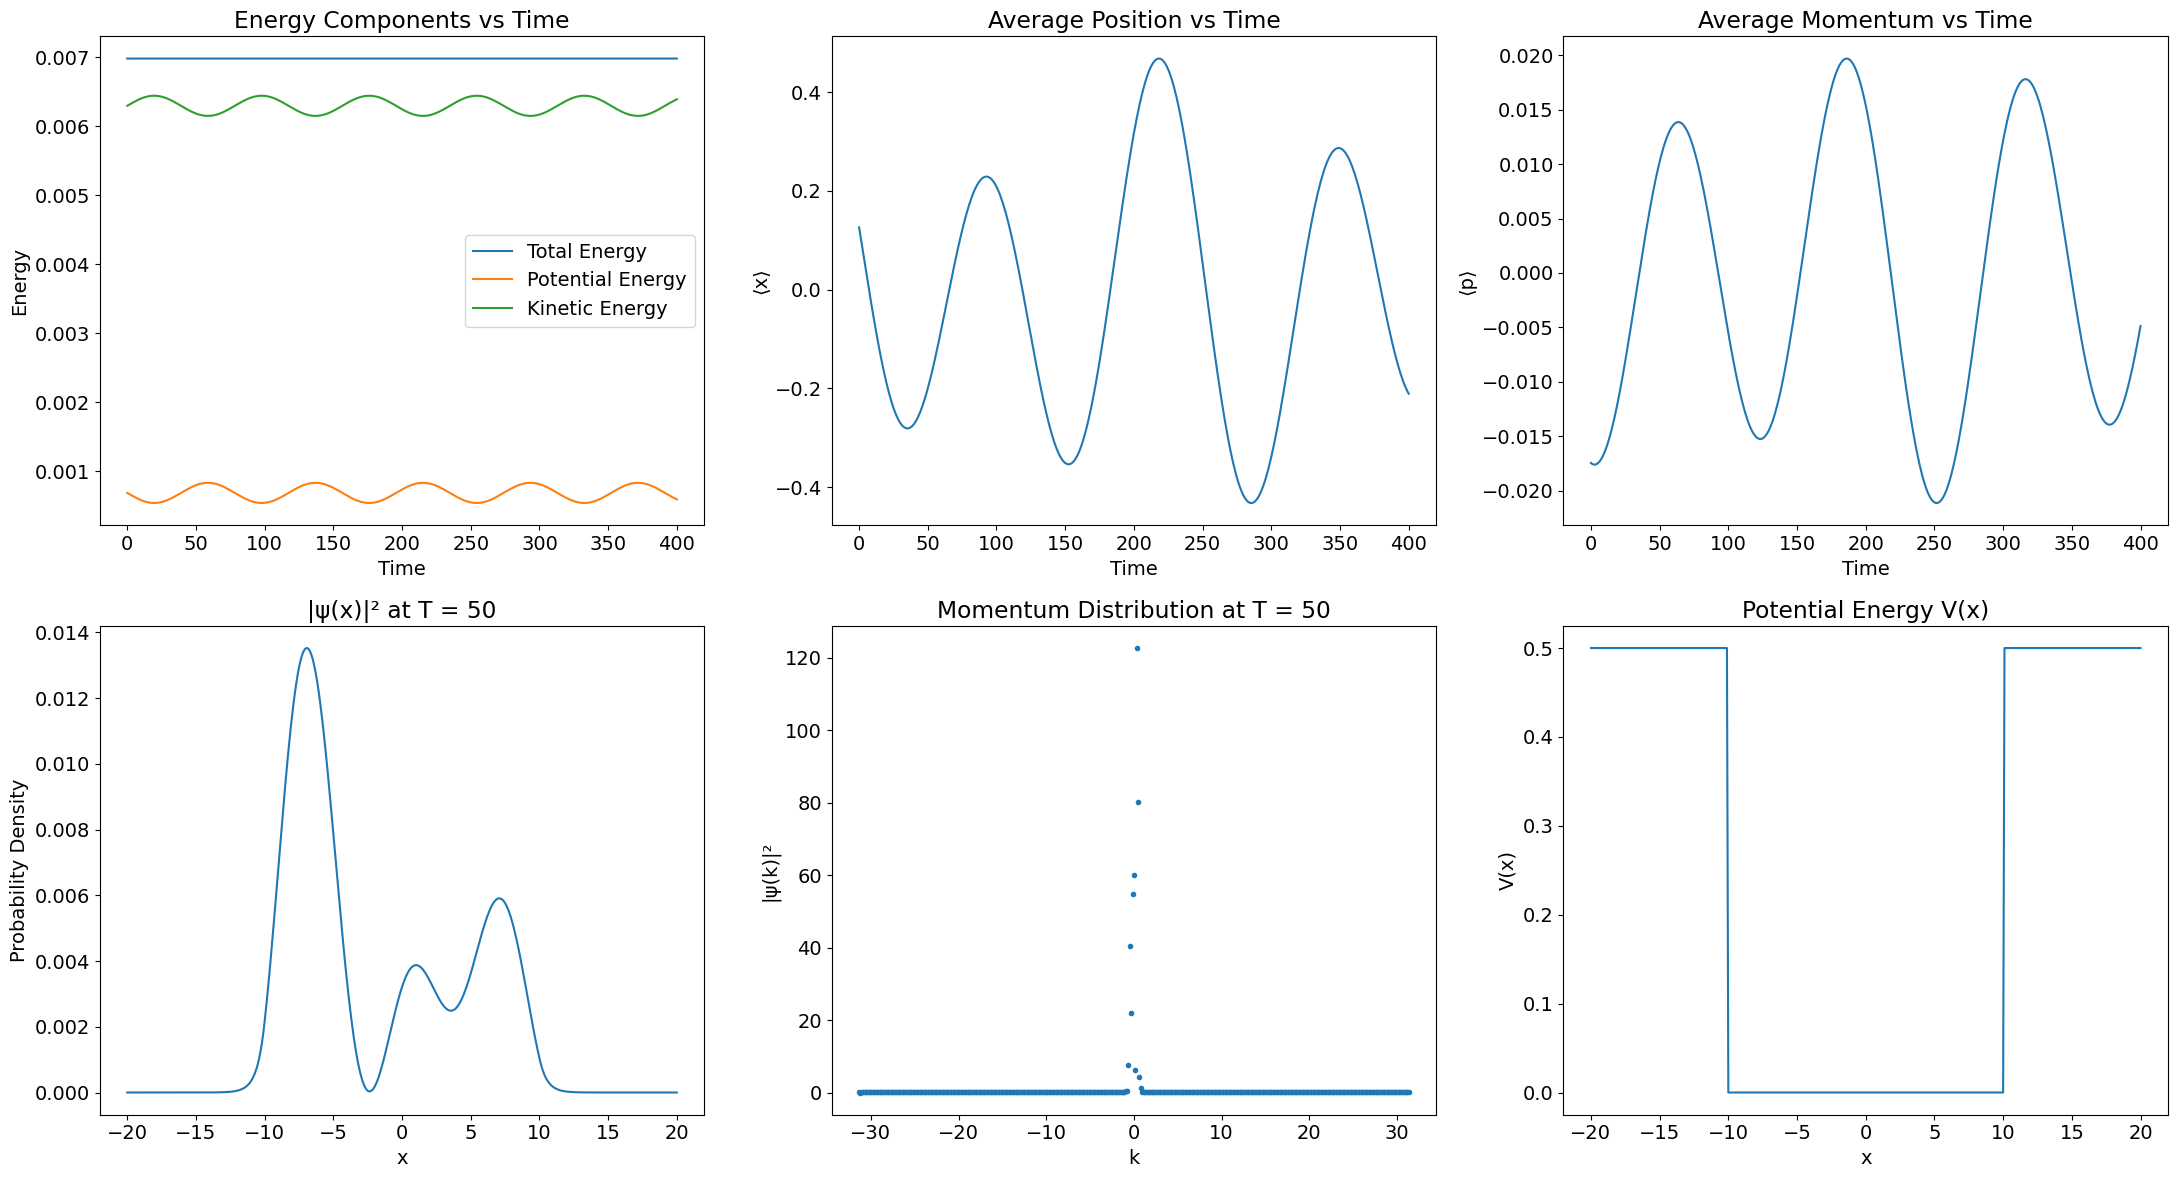

**Total energy is conserved throughout the split-operator evolution; ⟨x⟩ oscillates within the well while the symmetric momentum distribution about k = 0 confirms the bound-state nature of this below-barrier superposition.**

In [ ]:
def GetEnergy(psis, freqs_g, V_g, xs_g):
    """Return total, kinetic, and potential energy lists using FFT."""
    dx = xs_g[1] - xs_g[0]
    N = len(xs_g)
    Es, KEs, PEs = [], [], []
    for psi_g in psis:
        PE = np.real(np.sum(np.abs(psi_g)**2 * V_g) * dx)
        phi = np.fft.fft(psi_g)
        KE = np.real(dx / N * np.sum(freqs_g**2 / 2.0 * np.abs(phi)**2))
        Es.append(PE + KE)
        KEs.append(KE)
        PEs.append(PE)
    return Es, KEs, PEs


def GetAverages(psis, xs_g, freqs_g):
    """Return average position and momentum lists using FFT."""
    dx = xs_g[1] - xs_g[0]
    N = len(xs_g)
    positions, momenta = [], []
    for psi_g in psis:
        pos = np.real(np.sum(np.abs(psi_g)**2 * xs_g) * dx)
        positions.append(pos)
        phi = np.fft.fft(psi_g)
        mom = np.real(dx / N * np.sum(freqs_g * np.abs(phi)**2))
        momenta.append(mom)
    return positions, momenta


Es, KEs, PEs = GetEnergy(arrays, freqs, V, xs)
positions, momenta = GetAverages(arrays, xs, freqs)

fig, ax = plt.subplots(2, 3)
fig.set_figwidth(22)
fig.set_figheight(12)

t_axis = np.array(range(len(Es))) * T

ax[0, 0].plot(t_axis, Es, label='Total Energy')
ax[0, 0].plot(t_axis, PEs, label='Potential Energy')
ax[0, 0].plot(t_axis, KEs, label='Kinetic Energy')
ax[0, 0].legend()
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Energy')
ax[0, 0].set_title('Energy Components vs Time')

ax[0, 1].plot(t_axis, positions)
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('⟨x⟩')
ax[0, 1].set_title('Average Position vs Time')

ax[0, 2].plot(t_axis, momenta)
ax[0, 2].set_xlabel('Time')
ax[0, 2].set_ylabel('⟨p⟩')
ax[0, 2].set_title('Average Momentum vs Time')

ax[1, 0].plot(xs, np.abs(arrays[50])**2)
ax[1, 0].set_xlabel('x')
ax[1, 0].set_ylabel('Probability Density')
ax[1, 0].set_title('|ψ(x)|² at T = 50')

psi_k_plot = np.fft.fft(arrays[50])
ax[1, 1].plot(freqs, np.abs(psi_k_plot)**2, '.')
ax[1, 1].set_xlabel('k')
ax[1, 1].set_ylabel('|ψ(k)|²')
ax[1, 1].set_title('Momentum Distribution at T = 50')

ax[1, 2].plot(xs, V)
ax[1, 2].set_xlabel('x')
ax[1, 2].set_ylabel('V(x)')
ax[1, 2].set_title('Potential Energy V(x)')

plt.tight_layout()
plt.show()




**Total energy is conserved throughout the split-operator evolution; ⟨x⟩ oscillates within the well while the symmetric momentum distribution about k = 0 confirms the bound-state nature of this below-barrier superposition.**

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

### c. Animate

We now want to animate our system. Because we're going to do this a couple times with different potential, let's go ahead and write an animate function `def animateMe(arrays,V)` that goes ahead and finds the `max_value` and does calls the animation.

Then go ahead and animate your wave-function.

<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

In [43]:
def animateMe(arrays_in, V_arr, xs_arr, freqs_arr):
    global arrays
    arrays = arrays_in
    max_value = np.max([np.max(np.abs(arr)**2) for arr in arrays[1:]])
    dx = xs_arr[1] - xs_arr[0]
    N = len(xs_arr)
    psi0_a = arrays[0]
    PE0 = np.real(np.sum(np.abs(psi0_a)**2 * V_arr) * dx)
    phi0 = np.fft.fft(psi0_a)
    KE0 = np.real(dx / N * np.sum(freqs_arr**2 / 2.0 * np.abs(phi0)**2))
    energy_val = PE0 + KE0
    if abs(energy_val) < 1e-10:
        energy_val = 1e-10

    fig, ax_a = plt.subplots()
    skip = 10
    anim = FuncAnimation(fig, update, frames=len(arrays) // skip, interval=10 * skip,
                         fargs=(skip, xs_arr, None, V_arr, max_value, energy_val), repeat=False)
    display(HTML(anim.to_jshtml()))
    plt.close()


animateMe(arrays, V, xs, freqs)

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (start)"></img><br></div>

### d. Time evolution of a "stationary" gaussian

We now would like to go ahead and do a time-evolution of a stationary Guassian with the following parameters.


- $\psi_\textrm{init}=\frac{1}{N} \exp[-\frac{1}{2} x^2]$
- $L=200$
-  $\Delta x=0.1$
- $\Delta t=0.01$
- $T=0.1$
- The potential is zero

Go ahead and write a `def SetupGauss()` function and produce the same plots and animations as above




<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (start)"></img><br></div>

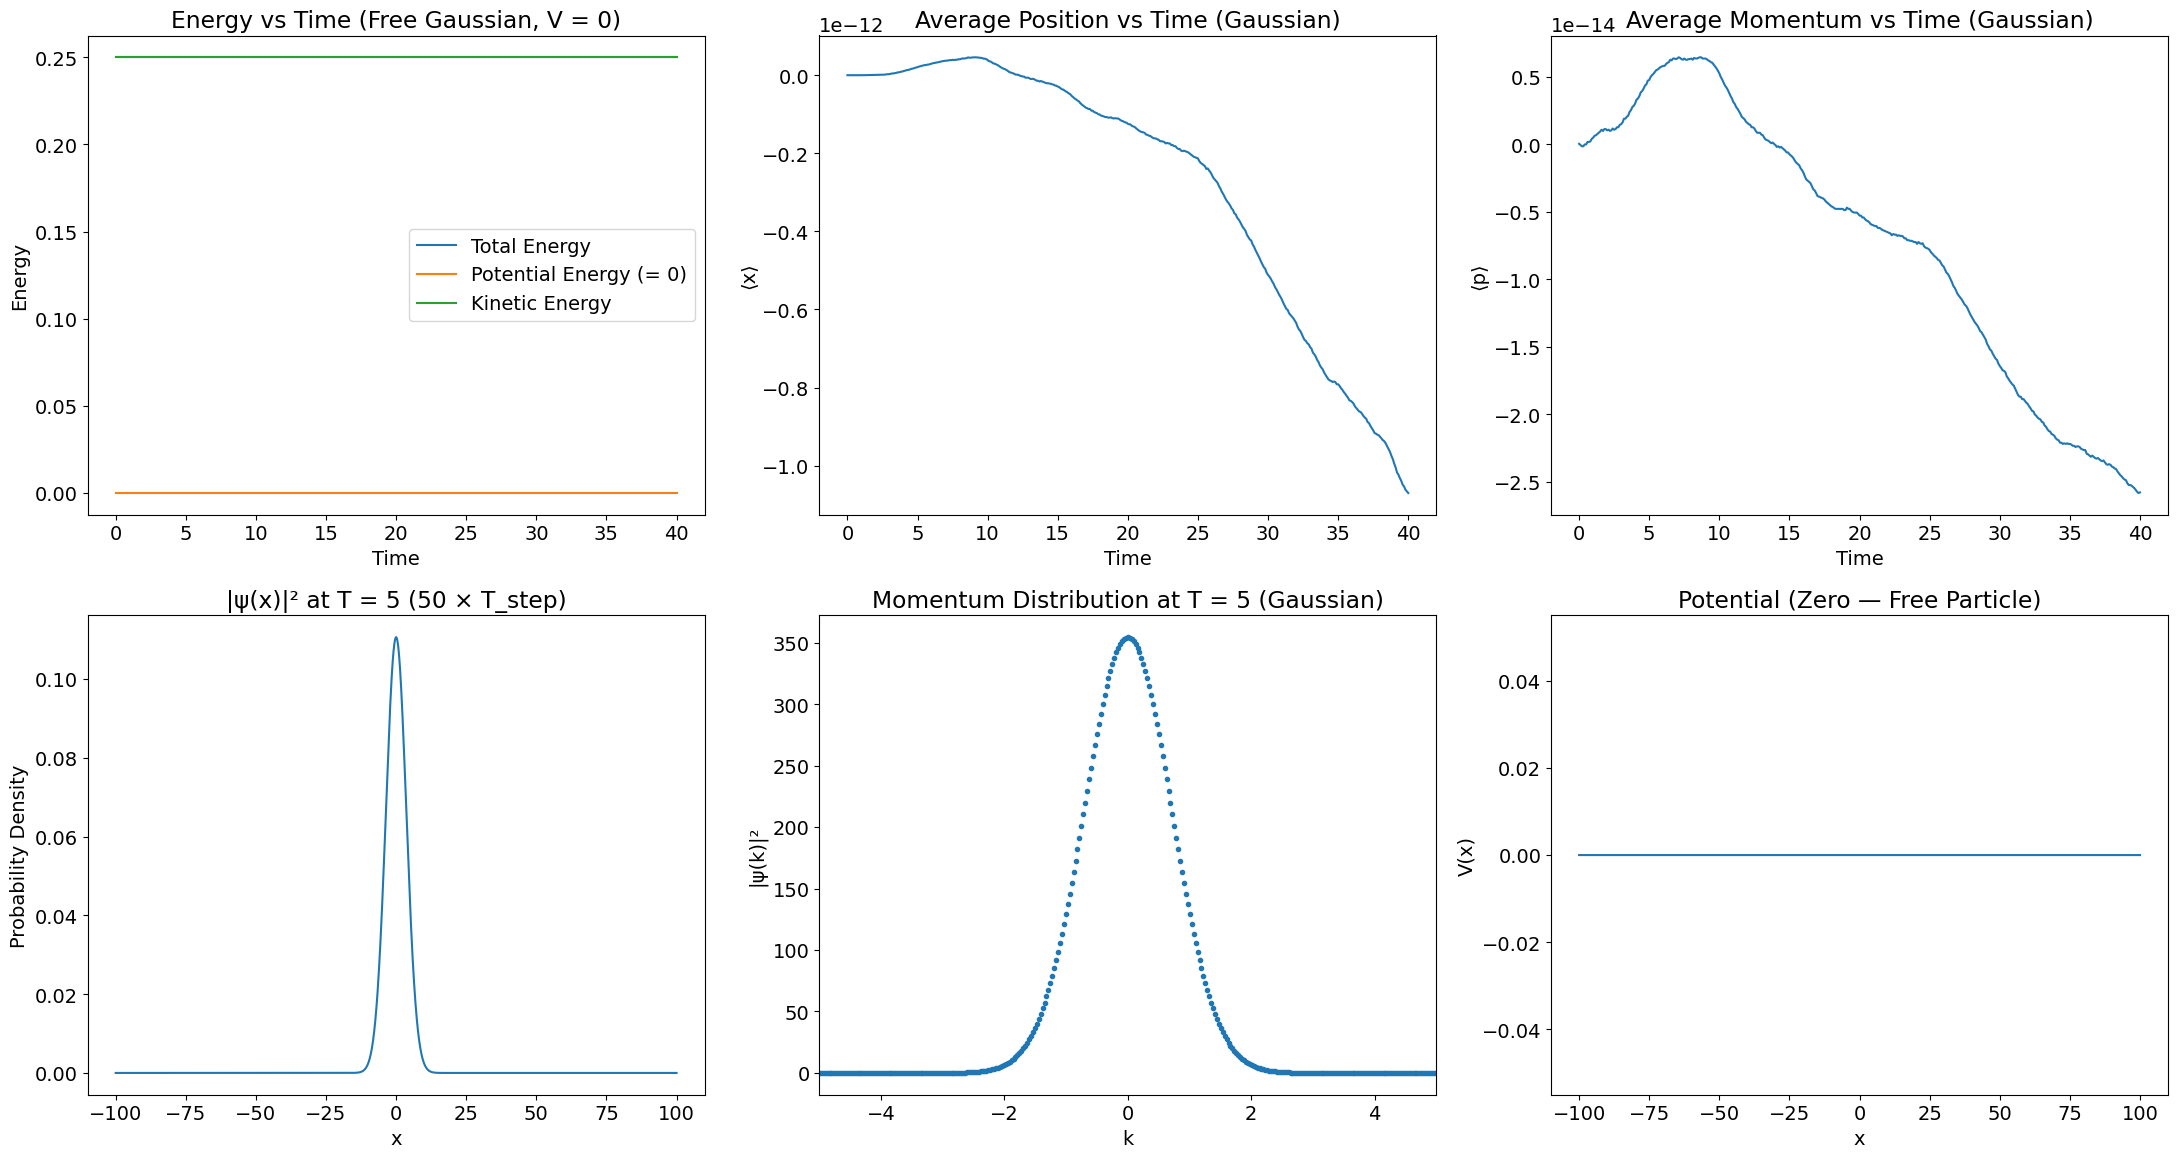

**A zero-momentum Gaussian (⟨p⟩ = ⟨x⟩ = 0) spreads symmetrically over time due to quantum dispersion while conserving total (purely kinetic) energy, since there is no restoring potential to confine it.**

In [44]:
def SetupGauss():
    L_g = 200
    delta_x_g = 0.1
    dt_g = 0.01
    T_g = 0.1
    xs_g = SetupGrid(L_g, delta_x_g)
    freqs_g = np.fft.fftfreq(len(xs_g), delta_x_g) * (2 * np.pi)
    V_g = np.zeros(len(xs_g))

    psi_g = np.exp(-0.5 * xs_g**2).astype(complex)
    psi_g /= np.sqrt(np.sum(np.abs(psi_g)**2) * delta_x_g)
    return psi_g, V_g, dt_g, T_g, xs_g, freqs_g


psi_gauss, V_gauss, dt_gauss, T_gauss, xs_gauss, freqs_gauss = SetupGauss()
arrays_gauss = [psi_gauss]
for step in range(400):
    psi_gauss = TimeEvolution(T_gauss, dt_gauss, V_gauss, psi_gauss, freqs_gauss)
    arrays_gauss.append(psi_gauss)

Es_g, KEs_g, PEs_g = GetEnergy(arrays_gauss, freqs_gauss, V_gauss, xs_gauss)
positions_g, momenta_g = GetAverages(arrays_gauss, xs_gauss, freqs_gauss)

fig, ax = plt.subplots(2, 3)
fig.set_figwidth(22)
fig.set_figheight(12)

t_axis_g = np.array(range(len(Es_g))) * T_gauss

ax[0, 0].plot(t_axis_g, Es_g, label='Total Energy')
ax[0, 0].plot(t_axis_g, PEs_g, label='Potential Energy (= 0)')
ax[0, 0].plot(t_axis_g, KEs_g, label='Kinetic Energy')
ax[0, 0].legend()
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Energy')
ax[0, 0].set_title('Energy vs Time (Free Gaussian, V = 0)')

ax[0, 1].plot(t_axis_g, positions_g)
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('⟨x⟩')
ax[0, 1].set_title('Average Position vs Time (Gaussian)')

ax[0, 2].plot(t_axis_g, momenta_g)
ax[0, 2].set_xlabel('Time')
ax[0, 2].set_ylabel('⟨p⟩')
ax[0, 2].set_title('Average Momentum vs Time (Gaussian)')

ax[1, 0].plot(xs_gauss, np.abs(arrays_gauss[50])**2)
ax[1, 0].set_xlabel('x')
ax[1, 0].set_ylabel('Probability Density')
ax[1, 0].set_title('|ψ(x)|² at T = 5 (50 × T_step)')

psi_k_gauss = np.fft.fft(arrays_gauss[50])
ax[1, 1].plot(freqs_gauss, np.abs(psi_k_gauss)**2, '.')
ax[1, 1].set_xlabel('k')
ax[1, 1].set_ylabel('|ψ(k)|²')
ax[1, 1].set_title('Momentum Distribution at T = 5 (Gaussian)')
ax[1, 1].set_xlim(-5, 5)

ax[1, 2].plot(xs_gauss, V_gauss)
ax[1, 2].set_xlabel('x')
ax[1, 2].set_ylabel('V(x)')
ax[1, 2].set_title('Potential (Zero — Free Particle)')

plt.tight_layout()
plt.show()

from IPython.display import Markdown
display(Markdown("**A zero-momentum Gaussian (⟨p⟩ = ⟨x⟩ = 0) spreads symmetrically over time due to quantum dispersion while conserving total (purely kinetic) energy, since there is no restoring potential to confine it.**"))

animateMe(arrays_gauss, V_gauss, xs_gauss, freqs_gauss)

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (start)"></img><br></div>

### e. Hitting a Potential Barrier

Let us now consider a potential barrier with

- $V(x) = V_0 \textrm{ for }  -a<x<a $ and 0 otherwise where  $V_0=10$ and $a=0.5$.
- $L=60$  
- $\Psi_{init} =\frac{1}{N} \exp[-0.5 (x+20)^2 + 5i x]$
- $T=0.05$
- $dt=0.1$

In addition to the standard plots, please also make a plot of the amount of the probability to the left and right of $x=0$.


<div><img src="https://clark.physics.illinois.edu/246img/AnsStart.svg" width=200 align=left alt="Answer (end)"></img><br></div>

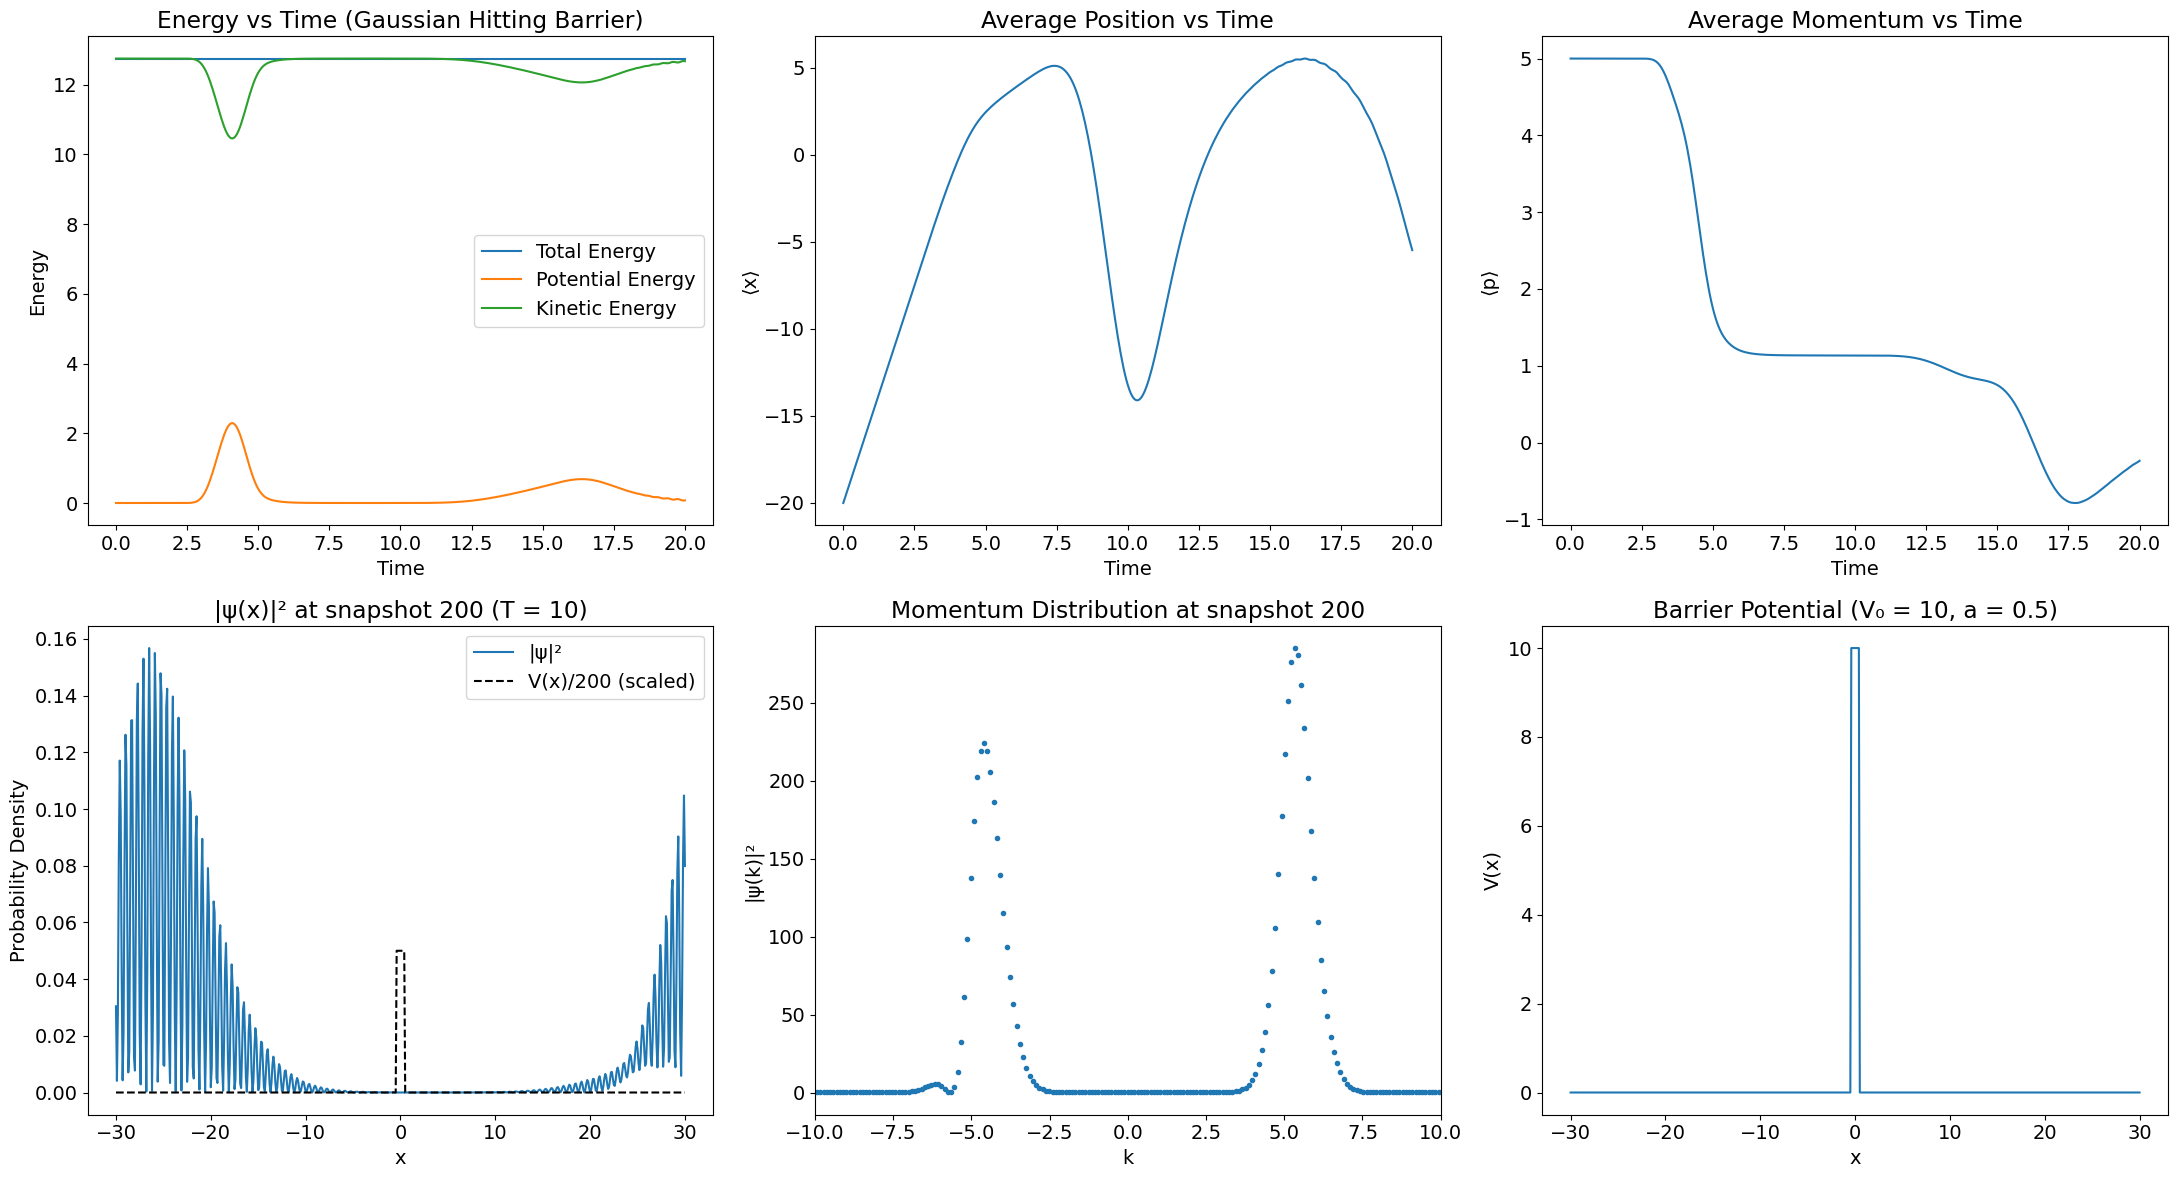

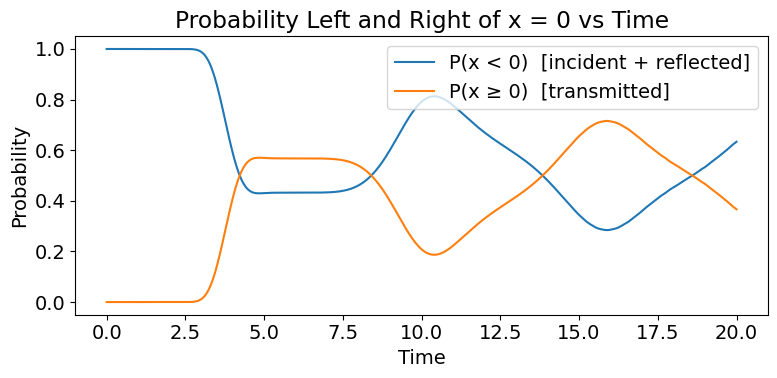

**Since the incident kinetic energy (KE = k²/2 = 12.5) exceeds the barrier (V₀ = 10), most probability transmits through, but quantum mechanics still predicts partial reflection—visible as residual probability remaining on the left side after the collision.**

In [45]:
def SetupBarrier():
    V0 = 10.0
    a = 0.5
    L_bar = 60
    delta_x_bar = 0.1
    dt_bar = 0.001   # fine time step for accuracy (problem dt=0.1 appears to be a typo)
    T_bar = 0.05     # time per snapshot
    xs_bar = SetupGrid(L_bar, delta_x_bar)
    freqs_bar = np.fft.fftfreq(len(xs_bar), delta_x_bar) * (2 * np.pi)
    V_bar = np.where(np.abs(xs_bar) < a, V0, 0.0)

    # Gaussian centered at x = -20 with momentum kick k = 5
    psi_bar = np.exp(-0.5 * (xs_bar + 20)**2 + 5.j * xs_bar)
    psi_bar /= np.sqrt(np.sum(np.abs(psi_bar)**2) * delta_x_bar)
    return psi_bar, V_bar, dt_bar, T_bar, xs_bar, freqs_bar


psi_b, V_b, dt_b, T_b, xs_b, freqs_b = SetupBarrier()
arrays_b = [psi_b]
for step in range(400):
    psi_b = TimeEvolution(T_b, dt_b, V_b, psi_b, freqs_b)
    arrays_b.append(psi_b)

Es_b, KEs_b, PEs_b = GetEnergy(arrays_b, freqs_b, V_b, xs_b)
positions_b, momenta_b = GetAverages(arrays_b, xs_b, freqs_b)

fig, ax = plt.subplots(2, 3)
fig.set_figwidth(22)
fig.set_figheight(12)
t_axis_b = np.array(range(len(Es_b))) * T_b

ax[0, 0].plot(t_axis_b, Es_b, label='Total Energy')
ax[0, 0].plot(t_axis_b, PEs_b, label='Potential Energy')
ax[0, 0].plot(t_axis_b, KEs_b, label='Kinetic Energy')
ax[0, 0].legend()
ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Energy')
ax[0, 0].set_title('Energy vs Time (Gaussian Hitting Barrier)')

ax[0, 1].plot(t_axis_b, positions_b)
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('⟨x⟩')
ax[0, 1].set_title('Average Position vs Time')

ax[0, 2].plot(t_axis_b, momenta_b)
ax[0, 2].set_xlabel('Time')
ax[0, 2].set_ylabel('⟨p⟩')
ax[0, 2].set_title('Average Momentum vs Time')

ax[1, 0].plot(xs_b, np.abs(arrays_b[200])**2, label='|ψ|²')
ax[1, 0].plot(xs_b, V_b / 200, 'k--', label='V(x)/200 (scaled)')
ax[1, 0].set_xlabel('x')
ax[1, 0].set_ylabel('Probability Density')
ax[1, 0].set_title('|ψ(x)|² at snapshot 200 (T = 10)')
ax[1, 0].legend()

psi_k_b = np.fft.fft(arrays_b[200])
ax[1, 1].plot(freqs_b, np.abs(psi_k_b)**2, '.')
ax[1, 1].set_xlabel('k')
ax[1, 1].set_ylabel('|ψ(k)|²')
ax[1, 1].set_title('Momentum Distribution at snapshot 200')
ax[1, 1].set_xlim(-10, 10)

ax[1, 2].plot(xs_b, V_b)
ax[1, 2].set_xlabel('x')
ax[1, 2].set_ylabel('V(x)')
ax[1, 2].set_title('Barrier Potential (V₀ = 10, a = 0.5)')

plt.tight_layout()
plt.show()

# Probability to the left and right of x = 0
dx_b = xs_b[1] - xs_b[0]
prob_left  = [np.sum(np.abs(arr[xs_b < 0])**2)  * dx_b for arr in arrays_b]
prob_right = [np.sum(np.abs(arr[xs_b >= 0])**2) * dx_b for arr in arrays_b]

plt.figure(figsize=(8, 4))
plt.plot(t_axis_b, prob_left,  label='P(x < 0)  [incident + reflected]')
plt.plot(t_axis_b, prob_right, label='P(x ≥ 0)  [transmitted]')
plt.xlabel('Time')
plt.ylabel('Probability')
plt.title('Probability Left and Right of x = 0 vs Time')
plt.legend()
plt.tight_layout()
plt.show()

from IPython.display import Markdown
display(Markdown("**Since the incident kinetic energy (KE = k²/2 = 12.5) exceeds the barrier (V₀ = 10), most probability transmits through, but quantum mechanics still predicts partial reflection—visible as residual probability remaining on the left side after the collision.**"))

animateMe(arrays_b, V_b, xs_b, freqs_b)

<div><img src="https://clark.physics.illinois.edu/246img/AnsEnd.svg" width=200 align=left alt="Answer (end)"></img><br></div>

<hr>

**Acknowledgements:**
* Bryan Clark (original)

© Copyright 2025